# Análise Exploratória (EDA)

**Projeto:** Social Wave — Otimização de Campanhas de Marketing  
**Fase:** Diagnóstico (Fase 1)  
**Objetivo:** Entender o passado antes de propor o futuro  

---

## Perguntas que este notebook responde

| # | Pergunta | O que descobrimos | Seção |
|---|----------|-------------------|-------|
| **1.1** | Qual o **CPA médio por canal** e como ele evoluiu ao longo do tempo? | Canais eficientes vs. ineficientes | 3.1 |
| **1.2** | Qual o **share de gasto** e **share de conversões** por canal hoje? | Desbalanceamento entre investimento e retorno | 3.2 |
| **1.3** | Existe **correlação entre aumento de gasto e elevação de CPA** dentro de cada canal? | Sinais de retornos decrescentes | 3.3 |
| **1.4** | Qual o **CTR e taxa de conversão** por canal? | Onde o funil 'vaza' | 3.4 |

---

## Dados de Entrada
Base limpa do notebook `notebook_00_contexto_dicionario_e_tratamento.ipynb`  
Período: Outubro a Dezembro de 2023  
Registros: [será preenchido após carga]  
Canais: 6 (Meta, Google, YouTube, Twitter, TikTok, LinkedIn)

---

## Entregáveis
- Tabela resumo por canal (CPA, CTR, Taxa de Conversão, Share)
- Gráficos: evolução temporal, distribuição, correlações
- Insights iniciais para o modelo de otimização

## Setup e Carregamento da Base processada no Notebook 00

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURAÇÕES VISUAIS
# ============================================================

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# ============================================================
# CONFIGURAÇÕES DE EXIBIÇÃO
# ============================================================

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ============================================================
# SEED PARA REPRODUTIBILIDADE
# ============================================================

np.random.seed(42)

# ============================================================
# CARREGAR BASE PROCESSADA (PICKLE)
# ============================================================

PICKLE_PATH = r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\data\campanhas_base_processada.pkl'

try:
    df = pd.read_pickle(PICKLE_PATH)
    
    print('=' * 60)
    print('BASE PROCESSADA CARREGADA')
    print('=' * 60)
    print(f'Fonte: {PICKLE_PATH}')
    print(f'Dimensoes: {df.shape[0]:,} registros x {df.shape[1]} colunas')
    print(f'Periodo: {df['Data da Coleta'].min()} a {df['Data da Coleta'].max()}')
    
    print(f'\n✅ Tipos preservados:')
    print(f'   • Data da Coleta: {df['Data da Coleta'].dtype}')
    print(f'   • Canal: {df['Canal'].dtype}')
    print(f'   • Gasto: {df['Gasto'].dtype}')
    print(f'   • Conversao: {df['Conversao'].dtype}')
    
    print(f'\nColunas disponiveis:')
    print(f'   {', '.join(df.columns.tolist())}')
    
except FileNotFoundError:
    print(f'❌ Base nao encontrada: {PICKLE_PATH}')
    print('   Execute o Notebook 00 primeiro para gerar a base limpa.')
    raise

print(f'\n📊 Primeiras linhas:')
print('\n')
display(df.head())

BASE PROCESSADA CARREGADA
Fonte: C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\data\campanhas_base_processada.pkl
Dimensoes: 23,315 registros x 9 colunas
Periodo: 2023-10-01 11:00:00 a 2023-12-24 23:00:00

✅ Tipos preservados:
   • Data da Coleta: datetime64[us]
   • Canal: str
   • Gasto: float64
   • Conversao: int64

Colunas disponiveis:
   ID, Canal, Data da Coleta, Impressoes Disponiveis, Consultas Correspondentes, Impressoes, Cliques, Gasto, Conversao

📊 Primeiras linhas:




,ID,Canal,Data da Coleta,Impressoes Disponiveis,Consultas Correspondentes,Impressoes,Cliques,Gasto,Conversao
0,ADSXJ0000001,Canal1,2023-11-02 03:00:00,82132,61776,43673,5,37.76,2
1,ADSXJ0000002,Canal1,2023-11-02 03:00:00,41889,33512,23919,4,18.76,2
2,ADSXJ0000003,Canal2,2023-12-18 04:00:00,2438114,1611096,1215019,1314,2481.57,44
3,ADSXJ0000004,Canal2,2023-12-19 04:00:00,2429576,1608711,1212549,1343,2513.02,36
4,ADSXJ0000005,Canal2,2023-12-18 03:00:00,2863336,1929554,1456197,1566,2912.62,30


## Cálculo de Métricas Derivadas

Objetivo: Transformar dados brutos em KPIs de marketing.

Fórmulas: CTR, Taxa de Conversão, CPC, CPA, CPM

In [2]:
print('=' * 60)
print('CÁLCULO DE MÉTRICAS DERIVADAS')
print('=' * 60)

# ============================================================
# MÉTRICAS DO FUNIL (Taxas)
# ============================================================

print('\n' + '-' * 60)
print('1. MÉTRICAS DO FUNIL')
print('-' * 60)

# CTR (Click-Through Rate): % de impressões que viraram cliques
# Indica: Atratividade do criativo/impacto do anúncio
df['CTR'] = (df['Cliques'] / df['Impressoes'] * 100).round(2)

# Taxa de Conversão: % de cliques que viraram conversões
# Indica: Eficiência do funil pós-clique (landing page, oferta)
df['Taxa_Conversao'] = (df['Conversao'] / df['Cliques'] * 100).round(2)

print('✅ CTR calculado: (Cliques / Impressoes) x 100')
print('✅ Taxa_Conversao calculada: (Conversao / Cliques) x 100')

# ============================================================
# MÉTRICAS DE CUSTO
# ============================================================

print('\n' + '-' * 60)
print('2. MÉTRICAS DE CUSTO')
print('-' * 60)

# CPC (Custo por Clique): Quanto paga por cada clique
# Indica: Custo do tráfego qualificado
df['CPC'] = (df['Gasto'] / df['Cliques']).round(2)

# CPA (Custo Por Aquisição): Quanto paga por cada conversão
# Indica: Eficiência de aquisição — KPI PRINCIPAL DO PROJETO
df['CPA'] = (df['Gasto'] / df['Conversao']).round(2)

# CPM (Custo por Mil Impressões): Custo de alcance
# Indica: Eficiência de veiculação
df['CPM'] = ((df['Gasto'] / df['Impressoes']) * 1000).round(2)

print('✅ CPC calculado: Gasto / Cliques')
print('✅ CPA calculado: Gasto / Conversao  [KPI PRINCIPAL]')
print('✅ CPM calculado: (Gasto / Impressoes) x 1000')

# ============================================================
# TRATAMENTO DE DIVISÃO POR ZERO
# ============================================================

print('\n' + '-' * 60)
print('3. TRATAMENTO DE DIVISÃO POR ZERO')
print('-' * 60)

# Onde Conversao = 0, CPA = infinito — vamos identificar
cpa_infinito = np.isinf(df['CPA']).sum()
print(f'⚠️ Registros com CPA infinito (Conversao=0): {cpa_infinito}')

# Flag para identificar registros sem conversão
df['Sem_Conversao'] = df['Conversao'] == 0

print(f'✅ Flag Sem_Conversao criada para análise separada')
print(f'   Estes registros serão excluídos do cálculo de CPA médio')
print(f'   Mas mantidos na análise de CTR e CPC')

# ============================================================
# MÉTRICAS DE ALCANCE
# ============================================================

print('\n' + '-' * 60)
print('4. MÉTRICAS DE ALCANCE')
print('-' * 60)

# Taxa de Impressão: % do inventário utilizado
df['Taxa_Impressao'] = (df['Impressoes'] / df['Impressoes Disponiveis'] * 100).round(2)

print('✅ Taxa_Impressao calculada: (Impressoes / Impressoes Disponiveis) x 100')

# ============================================================
# COMPONENTES TEMPORAIS (se ainda não existirem)
# ============================================================

print('\n' + '-' * 60)
print('5. COMPONENTES TEMPORAIS')
print('-' * 60)

if 'Data' not in df.columns:
    df['Data'] = df['Data da Coleta'].dt.date
    print('✅ Data extraída da coluna Data da Coleta')

if 'Ano_Mes' not in df.columns:
    df['Ano_Mes'] = df['Data da Coleta'].dt.to_period('M')
    print('✅ Ano_Mes extraído da Coluna Data da Coleta')

if 'Dia_Semana' not in df.columns:
    df['Dia_Semana'] = df['Data da Coleta'].dt.day_name()
    print('✅ Dia_Semana extraído da coluna Data da Coleta')

# ============================================================
# RESUMO DAS NOVAS COLUNAS
# ============================================================

print('\n' + '=' * 60)
print('📋 RESUMO DAS MÉTRICAS CRIADAS')
print('=' * 60)

metricas_novas = ['CTR', 'Taxa_Conversao', 'CPC', 'CPA', 'CPM', 'Taxa_Impressao']
print(f'\nNovas colunas: {len(metricas_novas)}')
for m in metricas_novas:
    print(f'   • {m}')

print(f'\n📊 Preview das métricas (primeiros 5 registros):')
display(df[['Canal', 'Gasto', 'Conversao', 'CTR', 'Taxa_Conversao', 'CPA', 'CPC']].head())

print(f'\n📊 Estatísticas descritivas das métricas:')
display(df[metricas_novas].describe().round(2))

CÁLCULO DE MÉTRICAS DERIVADAS

------------------------------------------------------------
1. MÉTRICAS DO FUNIL
------------------------------------------------------------
✅ CTR calculado: (Cliques / Impressoes) x 100
✅ Taxa_Conversao calculada: (Conversao / Cliques) x 100

------------------------------------------------------------
2. MÉTRICAS DE CUSTO
------------------------------------------------------------
✅ CPC calculado: Gasto / Cliques
✅ CPA calculado: Gasto / Conversao  [KPI PRINCIPAL]
✅ CPM calculado: (Gasto / Impressoes) x 1000

------------------------------------------------------------
3. TRATAMENTO DE DIVISÃO POR ZERO
------------------------------------------------------------
⚠️ Registros com CPA infinito (Conversao=0): 700
✅ Flag Sem_Conversao criada para análise separada
   Estes registros serão excluídos do cálculo de CPA médio
   Mas mantidos na análise de CTR e CPC

------------------------------------------------------------
4. MÉTRICAS DE ALCANCE
----------

,Canal,Gasto,Conversao,CTR,Taxa_Conversao,CPA,CPC
0,Canal1,37.76,2,0.01,40.00,18.88,7.55
1,Canal1,18.76,2,0.02,50.00,9.38,4.69
2,Canal2,2481.57,44,0.11,3.35,56.40,1.89
3,Canal2,2513.02,36,0.11,2.68,69.81,1.87
4,Canal2,2912.62,30,0.11,1.92,97.09,1.86



📊 Estatísticas descritivas das métricas:


,CTR,Taxa_Conversao,CPC,CPA,CPM,Taxa_Impressao
count,23315.00,23315.00,23315.00,23315.00,23315.00,23315.00
mean,9.50,3.55,0.33,inf,9.09,44.11
std,10.20,9.33,0.33,NaN,9.63,14.46
min,0.01,0.00,0.00,0.00,0.00,3.70
25%,0.30,1.41,0.09,3.64,1.91,34.30
50%,10.62,2.47,0.13,8.63,9.01,47.65
75%,15.45,3.06,0.53,26.94,14.20,54.37
max,100.00,100.00,7.55,inf,743.10,100.00


OBS.: 

⚠️ Sobre o CPA infinito
Quando Conversao = 0, a divisão Gasto / 0 resulta em inf. Isso é matematicamente correto (gastou e não converteu = custo infinito por conversão), mas para análise agregada por canal usaremos média ponderada ou filtro de registros com conversão.

## Tabela Executiva por Canal

Agrupamento os dados por canal e calculo das métricas agregadas. 

Esta tabela é o diagnóstico principal — ela mostra, em uma única visão, qual canal é eficiente, qual é caro, onde está o desbalanceamento.

In [3]:
print('=' * 60)
print('📊 TABELA EXECUTIVA POR CANAL')
print('=' * 60)

# ============================================================
# MAPEAMENTO DE CANAIS
# ============================================================

print('\n' + '-' * 60)
print('MAPEAMENTO DE CANAIS')
print('-' * 60)

mapeamento_canais = {
    'Canal1': 'Meta Ads',
    'Canal2': 'Google Search',
    'Canal3': 'YouTube Ads',
    'Canal4': 'Twitter Ads',
    'Canal5': 'TikTok',
    'Canal6': 'LinkedIn Ads'
}

df['Canal_Nome'] = df['Canal'].map(mapeamento_canais)

print('✅ Canal_Nome criado:')
for codigo, nome in mapeamento_canais.items():
    print(f'   {codigo} -> {nome}')

# ============================================================
# AGREGAÇÃO POR CANAL
# ============================================================

# Agrupar por canal e somar métricas brutas
resumo = df.groupby('Canal_Nome').agg({
    'Gasto': 'sum',
    'Conversao': 'sum',
    'Impressoes': 'sum',
    'Cliques': 'sum',
    'ID': 'count'  # quantidade de registros/campanhas
}).round(2)

# Renomear colunas
resumo.columns = ['Gasto_Total', 'Conversao_Total', 'Impressoes_Total', 'Cliques_Total', 'Campanhas']

# ============================================================
# CÁLCULO DE MÉTRICAS AGREGADAS
# ============================================================

# CTR agregado: cliques totais / impressões totais
resumo['CTR'] = (resumo['Cliques_Total'] / resumo['Impressoes_Total'] * 100).round(2)

# Taxa de Conversão agregada: conversões totais / cliques totais
resumo['Taxa_Conversao'] = (resumo['Conversao_Total'] / resumo['Cliques_Total'] * 100).round(2)

# CPA agregado: gasto total / conversões totais (média ponderada correta)
resumo['CPA'] = (resumo['Gasto_Total'] / resumo['Conversao_Total']).round(2)

# CPC agregado: gasto total / cliques totais
resumo['CPC'] = (resumo['Gasto_Total'] / resumo['Cliques_Total']).round(2)

# CPM agregado
resumo['CPM'] = ((resumo['Gasto_Total'] / resumo['Impressoes_Total']) * 1000).round(2)

# ============================================================
# SHARES (PESOS RELATIVOS)
# ============================================================

print('\n' + '-' * 60)
print('SHARES DE GASTO E CONVERSÃO')
print('-' * 60)

gasto_total_geral = resumo['Gasto_Total'].sum()
conversao_total_geral = resumo['Conversao_Total'].sum()

resumo['Share_Gasto'] = (resumo['Gasto_Total'] / gasto_total_geral * 100).round(2)
resumo['Share_Conversao'] = (resumo['Conversao_Total'] / conversao_total_geral * 100).round(2)

# Diferença entre share de gasto e share de conversão
# Positivo = sobre-investido | Negativo = sub-investido
resumo['Diferenca_Share'] = (resumo['Share_Gasto'] - resumo['Share_Conversao']).round(2)

print('✅ Share_Gasto: % do investimento total por canal')
print('✅ Share_Conversao: % das conversões totais por canal')
print('✅ Diferenca_Share: desbalanceamento (positivo = sobre-investido)')

# ============================================================
# ORDENAR E EXIBIR
# ============================================================

print('\n' + '-' * 60)
print('TABELA EXECUTIVA')
print('-' * 60)

# Ordenar por CPA (menor = mais eficiente)
resumo = resumo.sort_values('CPA')

# Selecionar colunas para exibição
colunas_display = [
    'Gasto_Total', 'Conversao_Total', 'CPA', 'CTR', 
    'Taxa_Conversao', 'Share_Gasto', 'Share_Conversao', 'Diferenca_Share'
]

print('\n📋 Ordenado por CPA (menor = mais eficiente):')
print(resumo[colunas_display].to_string())

# ============================================================
# INSIGHTS AUTOMÁTICOS
# ============================================================

print('\n' + '=' * 60)
print('INSIGHTS INICIAIS')
print('=' * 60)

# Canal mais eficiente
canal_top = resumo['CPA'].idxmin()
cpa_top = resumo.loc[canal_top, 'CPA']

# Canal menos eficiente
canal_bottom = resumo['CPA'].idxmax()
cpa_bottom = resumo.loc[canal_bottom, 'CPA']

# Canal mais investido
canal_maior_gasto = resumo['Share_Gasto'].idxmax()

# Canal com maior desbalanceamento positivo (sobre-investido)
canal_sobre_investido = resumo['Diferenca_Share'].idxmax()
diff_sobre = resumo.loc[canal_sobre_investido, 'Diferenca_Share']

# Canal com maior desbalanceamento negativo (sub-investido)
canal_sub_investido = resumo['Diferenca_Share'].idxmin()
diff_sub = resumo.loc[canal_sub_investido, 'Diferenca_Share']

#print(f'\nMAIS EFICIENTE: {canal_top} (CPA: ${cpa_top:.2f})')
#print(f'MENOS EFICIENTE: {canal_bottom} (CPA: ${cpa_bottom:.2f})')
#print(f'   Diferença de eficiência: {((cpa_bottom / cpa_top) - 1) * 100:.1f}% mais caro')
print(f'\nMAIS EFICIENTE: {canal_top} (CPA: ${cpa_top:.2f})')
print(f'MENOS EFICIENTE: {canal_bottom} (CPA: ${cpa_bottom:.2f})')
print(f'   Diferença de eficiência: {cpa_bottom / cpa_top:.1f}x mais caro')
print(f'   Diferença absoluta: ${cpa_bottom - cpa_top:.2f}')
print(f'   Diferença de eficiência: {cpa_bottom / cpa_top:.1f}x mais caro')

print(f'\nMAIOR INVESTIMENTO: {canal_maior_gasto} ({resumo.loc[canal_maior_gasto, 'Share_Gasto']:.1f}% do gasto total)')

print(f'\nDESBALANCEAMENTO:')
print(f'   SOBRE-INVESTIDO: {canal_sobre_investido} (+{diff_sobre:.1f}%)')
print(f'      → Gasta {resumo.loc[canal_sobre_investido, 'Share_Gasto']:.1f}% do orçamento para {resumo.loc[canal_sobre_investido, 'Share_Conversao']:.1f}% das conversões')
print(f'   SUB-INVESTIDO: {canal_sub_investido} ({diff_sub:.1f}%)')
print(f'      → Gasta {resumo.loc[canal_sub_investido, 'Share_Gasto']:.1f}% do orçamento para {resumo.loc[canal_sub_investido, 'Share_Conversao']:.1f}% das conversões')

# ============================================================
# SALVAR RESUMO PARA USO FUTURO
# ============================================================

print('\n' + '-' * 60)
print('SALVAR RESUMO')
print('-' * 60)

# Usar raw string (r'') para evitar erro de escape no Windows
caminho_salvar = r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\data\resumo_por_canal.pkl'
resumo.to_pickle(caminho_salvar)
print(f'✅ Resumo salvo: {caminho_salvar}')

print('\n' + '=' * 60)
print('TABELA EXECUTIVA COMPLETA!')
print('=' * 60)

📊 TABELA EXECUTIVA POR CANAL

------------------------------------------------------------
MAPEAMENTO DE CANAIS
------------------------------------------------------------
✅ Canal_Nome criado:
   Canal1 -> Meta Ads
   Canal2 -> Google Search
   Canal3 -> YouTube Ads
   Canal4 -> Twitter Ads
   Canal5 -> TikTok
   Canal6 -> LinkedIn Ads

------------------------------------------------------------
SHARES DE GASTO E CONVERSÃO
------------------------------------------------------------
✅ Share_Gasto: % do investimento total por canal
✅ Share_Conversao: % das conversões totais por canal
✅ Diferenca_Share: desbalanceamento (positivo = sobre-investido)

------------------------------------------------------------
TABELA EXECUTIVA
------------------------------------------------------------

📋 Ordenado por CPA (menor = mais eficiente):
               Gasto_Total  Conversao_Total   CPA   CTR  Taxa_Conversao  Share_Gasto  Share_Conversao  Diferenca_Share
Canal_Nome                            

## Gráfico de Barras: CPA por Canal

Visualização do CPA de cada canal em um gráfico de barras horizontal. 

Barras mais curtas = canais mais eficientes. É a versão visual da Tabela Executiva.

📊 GRÁFICO: CPA POR CANAL
✅ Figura salva: C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\images\01_cpa_por_canal.png




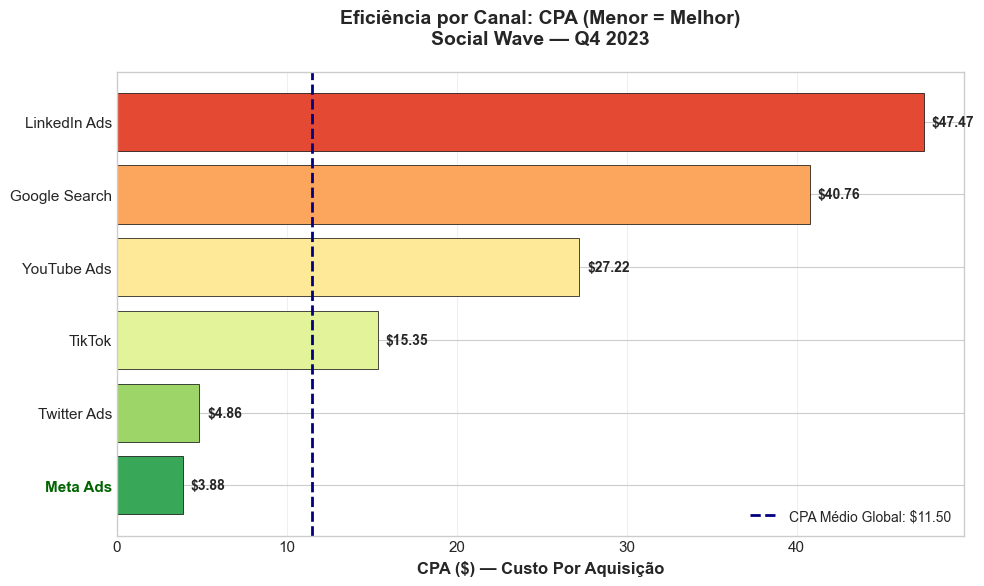


💡 INTERPRETAÇÃO

🏆 Mais eficiente: Meta Ads (CPA mais baixo)
📏 CPA médio global: $11.50 (linha tracejada)

Canais ACIMA da média (caros):
   ⚠️  TikTok: $15.35
   ⚠️  YouTube Ads: $27.22
   ⚠️  Google Search: $40.76
   ⚠️  LinkedIn Ads: $47.47

Canais ABAIXO da média (eficientes):
   ✅ Meta Ads: $3.88
   ✅ Twitter Ads: $4.86


In [4]:
print('=' * 60)
print('📊 GRÁFICO: CPA POR CANAL')
print('=' * 60)

# ============================================================
# PREPARAR DADOS
# ============================================================

# Usar o resumo já calculado na célula anterior
# Ordenar por CPA (menor para maior = mais eficiente para menos)
resumo_grafico = resumo.sort_values('CPA', ascending=True)

# ============================================================
# CRIAR GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Cores: verde para eficiente (CPA baixo), vermelho para caro (CPA alto)
cores = sns.color_palette('RdYlGn_r', n_colors=len(resumo_grafico))

# Barras horizontais
barras = ax.barh(
    y=resumo_grafico.index,
    width=resumo_grafico['CPA'],
    color=cores,
    edgecolor='black',
    linewidth=0.5
)

# ============================================================
# ADICIONAR VALORES NAS BARRAS
# ============================================================

for i, (canal, row) in enumerate(resumo_grafico.iterrows()):
    cpa = row['CPA']
    # Valor no final da barra
    ax.text(
        x=cpa + (resumo_grafico['CPA'].max() * 0.01),
        y=i,
        s=f'${cpa:.2f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

# ============================================================
# CONFIGURAR ESTILO
# ============================================================

ax.set_xlabel('CPA ($) — Custo Por Aquisição', fontsize=12, fontweight='bold')
ax.set_ylabel('')  # Remove label do eixo Y (nomes dos canais já bastam)
ax.set_title(
    'Eficiência por Canal: CPA (Menor = Melhor)\nSocial Wave — Q4 2023',
    fontsize=14,
    fontweight='bold',
    pad=20
)

# Linha de referência: CPA médio global
cpa_medio = (resumo_grafico['Gasto_Total'].sum() / resumo_grafico['Conversao_Total'].sum())
ax.axvline(
    x=cpa_medio,
    color='navy',
    linestyle='--',
    linewidth=2,
    label=f'CPA Médio Global: ${cpa_medio:.2f}'
)

# Destacar o canal mais eficiente
canal_top = resumo_grafico.index[0]
ax.get_yticklabels()[0].set_fontweight('bold')
ax.get_yticklabels()[0].set_color('darkgreen')

# Legenda e grid
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)

# Ajustar layout
plt.tight_layout()

# ============================================================
# SALVAR FIGURA
# ============================================================

figura_path = r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\images\01_cpa_por_canal.png'
plt.savefig(figura_path, dpi=150, bbox_inches='tight')
print(f'✅ Figura salva: {figura_path}')

# ============================================================
# EXIBIR
# ============================================================
print('\n')
plt.show()

print('\n' + '=' * 60)
print('💡 INTERPRETAÇÃO')
print('=' * 60)
print(f'\n🏆 Mais eficiente: {canal_top} (CPA mais baixo)')
print(f'📏 CPA médio global: ${cpa_medio:.2f} (linha tracejada)')
print(f'\nCanais ACIMA da média (caros):')
for canal in resumo_grafico[resumo_grafico['CPA'] > cpa_medio].index:
    print(f'   ⚠️  {canal}: ${resumo_grafico.loc[canal, 'CPA']:.2f}')
print(f'\nCanais ABAIXO da média (eficientes):')
for canal in resumo_grafico[resumo_grafico['CPA'] < cpa_medio].index:
    print(f'   ✅ {canal}: ${resumo_grafico.loc[canal, 'CPA']:.2f}')

| Elemento                 | Função                                             |
| ------------------------ | -------------------------------------------------- |
| **Barras horizontais**   | Nomes longos (LinkedIn Ads) cabem sem sobreposição |
| **Cores degradê**        | Verde = eficiente, Vermelho = caro (intuitivo)     |
| **Valores nas barras**   | Número exato do CPA sem precisar olhar eixo        |
| **Linha tracejada**      | CPA médio global — referência para comparar        |
| **Canal top em negrito** | Destaque automático para o melhor performer        |


## Gráfico de Barras Empilhadas: Share de Gasto vs. Conversão

Mostra lado a lado o share de gasto (quanto investimos) e o share de conversão (quanto retornamos) por canal. 

Canais onde as barras não têm o mesmo tamanho revelam desbalanceamento — o cerne do problema da Social Wave.

📊 GRÁFICO: SHARE DE GASTO VS. SHARE DE CONVERSÃO
✅ Figura salva: C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\images\02_share_gasto_vs_conversao.png




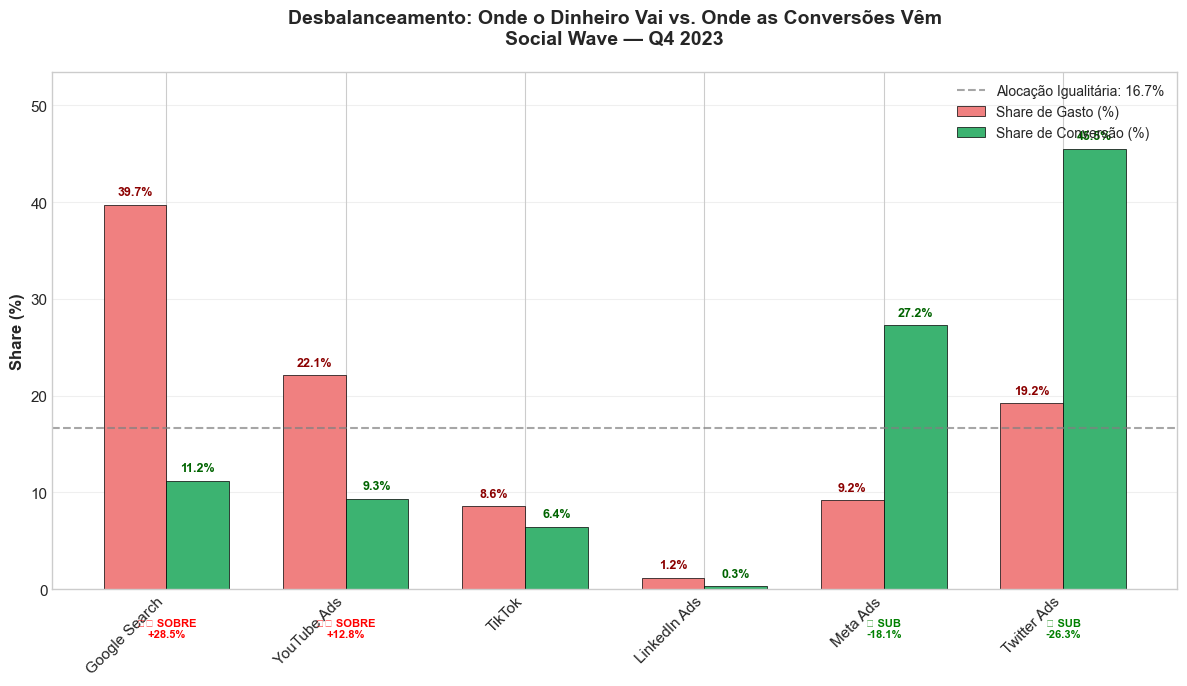


💡 INTERPRETAÇÃO

📊 REGRA DE OURO: Share de Gasto ≈ Share de Conversão
   Se gastamos 30% do orçamento em um canal, ele deve gerar ~30% das conversões.

⚠️ SOBRE-INVESTIDOS (gastam mais do que convertem):
   • Google Search: 39.7% gasto → 11.2% conversão (+28.5%)
   • YouTube Ads: 22.1% gasto → 9.3% conversão (+12.8%)

💡 SUB-INVESTIDOS (convertem mais do que gastam):
   • Meta Ads: 9.2% gasto → 27.2% conversão (-18.1%)
   • Twitter Ads: 19.2% gasto → 45.5% conversão (-26.3%)

✅ BALANCEADOS (diferença < 5%):
   • TikTok: 8.6% gasto → 6.4% conversão (+2.1%)
   • LinkedIn Ads: 1.2% gasto → 0.3% conversão (+0.9%)


In [5]:
print('=' * 60)
print('📊 GRÁFICO: SHARE DE GASTO VS. SHARE DE CONVERSÃO')
print('=' * 60)

# ============================================================
# PREPARAR DADOS
# ============================================================

# Ordenar por Diferenca_Share (do mais sobre-investido ao mais sub-investido)
resumo_share = resumo.sort_values('Diferenca_Share', ascending=False)

# ============================================================
# CRIAR GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(resumo_share))
largura = 0.35

# Barras: Share de Gasto
barras_gasto = ax.bar(
    x - largura/2,
    resumo_share['Share_Gasto'],
    largura,
    label='Share de Gasto (%)',
    color='lightcoral',
    edgecolor='black',
    linewidth=0.5
)

# Barras: Share de Conversão
barras_conv = ax.bar(
    x + largura/2,
    resumo_share['Share_Conversao'],
    largura,
    label='Share de Conversão (%)',
    color='mediumseagreen',
    edgecolor='black',
    linewidth=0.5
)

# ============================================================
# ADICIONAR VALORES NAS BARRAS
# ============================================================

for i, (canal, row) in enumerate(resumo_share.iterrows()):
    # Valor do gasto
    ax.text(
        x=i - largura/2,
        y=row['Share_Gasto'] + 1,
        s=f'{row['Share_Gasto']:.1f}%',
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='darkred'
    )
    # Valor da conversão
    ax.text(
        x=i + largura/2,
        y=row['Share_Conversao'] + 1,
        s=f'{row['Share_Conversao']:.1f}%',
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='darkgreen'
    )

# ============================================================
# CONFIGURAR ESTILO
# ============================================================

ax.set_ylabel('Share (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_xticks(x)
ax.set_xticklabels(resumo_share.index, rotation=45, ha='right')
ax.set_title(
    'Desbalanceamento: Onde o Dinheiro Vai vs. Onde as Conversões Vêm\nSocial Wave — Q4 2023',
    fontsize=14,
    fontweight='bold',
    pad=20
)

# Linha de referência: 100% / 6 canais = 16.67% (alocação igualitária)
alocacao_igual = 100 / 6
ax.axhline(
    y=alocacao_igual,
    color='gray',
    linestyle='--',
    linewidth=1.5,
    alpha=0.7,
    label=f'Alocação Igualitária: {alocacao_igual:.1f}%'
)

ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(resumo_share[['Share_Gasto', 'Share_Conversao']].max()) + 8)

# Destacar canais com grande desbalanceamento
for i, (canal, row) in enumerate(resumo_share.iterrows()):
    diff = row['Diferenca_Share']
    if abs(diff) > 10:
        cor = 'red' if diff > 0 else 'green'
        simbolo = '⚠️ SOBRE' if diff > 0 else '💡 SUB'
        ax.text(
            x=i,
            y=-5,
            s=f'{simbolo}\n{diff:+.1f}%',
            ha='center',
            fontsize=8,
            color=cor,
            fontweight='bold'
        )

plt.tight_layout()

# ============================================================
# SALVAR FIGURA
# ============================================================

figura_path = r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\images\02_share_gasto_vs_conversao.png'
plt.savefig(figura_path, dpi=150, bbox_inches='tight')
print(f'✅ Figura salva: {figura_path}')

# ============================================================
# EXIBIR
# ============================================================
print('\n')
plt.show()

print('\n' + '=' * 60)
print('💡 INTERPRETAÇÃO')
print('=' * 60)

print(f'\n📊 REGRA DE OURO: Share de Gasto ≈ Share de Conversão')
print(f'   Se gastamos 30% do orçamento em um canal, ele deve gerar ~30% das conversões.')

print(f'\n⚠️ SOBRE-INVESTIDOS (gastam mais do que convertem):')
sobre = resumo_share[resumo_share['Diferenca_Share'] > 5]
for canal in sobre.index:
    row = sobre.loc[canal]
    print(f'   • {canal}: {row['Share_Gasto']:.1f}% gasto → {row['Share_Conversao']:.1f}% conversão ({row['Diferenca_Share']:+.1f}%)')

print(f'\n💡 SUB-INVESTIDOS (convertem mais do que gastam):')
sub = resumo_share[resumo_share['Diferenca_Share'] < -5]
for canal in sub.index:
    row = sub.loc[canal]
    print(f'   • {canal}: {row['Share_Gasto']:.1f}% gasto → {row['Share_Conversao']:.1f}% conversão ({row['Diferenca_Share']:+.1f}%)')

print(f'\n✅ BALANCEADOS (diferença < 5%):')
balanceados = resumo_share[abs(resumo_share['Diferenca_Share']) <= 5]
for canal in balanceados.index:
    row = balanceados.loc[canal]
    print(f'   • {canal}: {row['Share_Gasto']:.1f}% gasto → {row['Share_Conversao']:.1f}% conversão ({row['Diferenca_Share']:+.1f}%)')

| Situação                           | O que significa                  | Ação sugerida                   |
| ---------------------------------- | -------------------------------- | ------------------------------- |
| **Barra laranja > barra verde**       | Gasta mais do que converte       | Reduzir investimento            |
| **Barra verde > barra laranja**       | Converte mais do que gasta       | Aumentar investimento           |
| **Barras alinhadas**               | Alocação proporcional ao retorno | Manter ou ajustar marginalmente |
| **Ambas abaixo da linha vermelha** | Canal com pouco volume           | Avaliar se vale a pena manter   |


## Gráfico de Dispersão: Gasto vs. CPA por Canal

Plota cada registro (campanha) em um gráfico de dispersão, com gasto no eixo X e CPA no eixo Y, separado por cor para cada canal. 

Se os pontos sobem à medida que o gasto aumenta, isso indica retornos decrescentes — um dos pilares para justificar a realocação de orçamento.

📊 GRÁFICO: GASTO VS. CPA POR CANAL

📊 Registros com CPA válido (Conversao > 0): 22,615
   Registros excluídos (Conversao = 0): 700
✅ Figura salva: C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\images\03_gasto_vs_cpa_scatter.png


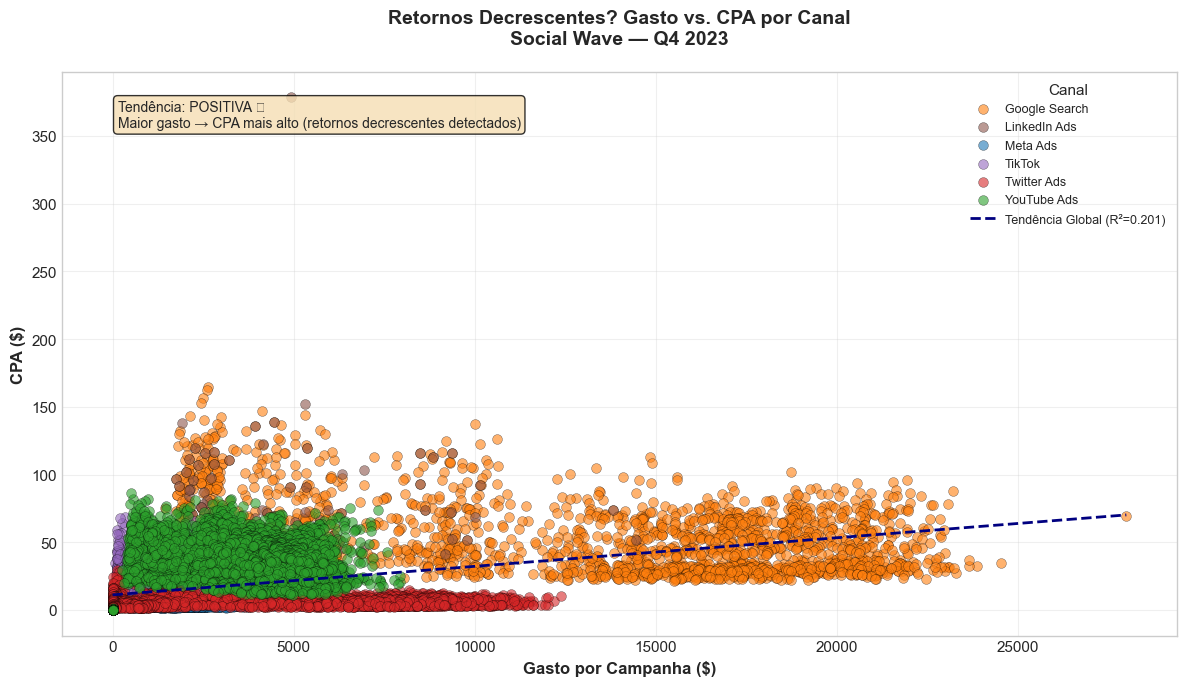


📊 CORRELAÇÃO GASTO vs. CPA POR CANAL

Canal                Correlação         R² Interpretação
----------------------------------------------------------------------
Google Search            -0.421      0.177   ✅ Escala benéfica
LinkedIn Ads             +0.281      0.079   ➖ Sem relação clara
Meta Ads                 +0.165      0.027   ➖ Sem relação clara
TikTok                   -0.089      0.008   ➖ Sem relação clara
Twitter Ads              +0.260      0.068   ➖ Sem relação clara
YouTube Ads              -0.119      0.014   ➖ Sem relação clara

📊 CORRELAÇÃO GLOBAL: +0.448 (R² = 0.201)
   p-value: 0.0000 (Significativo)


In [7]:
print('=' * 60)
print('📊 GRÁFICO: GASTO VS. CPA POR CANAL')
print('=' * 60)

# ============================================================
# PREPARAR DADOS
# ============================================================

# Filtrar apenas registros com conversão > 0 (CPA finito)
df_scatter = df[df['Conversao'] > 0].copy()

print(f'\n📊 Registros com CPA válido (Conversao > 0): {len(df_scatter):,}')
print(f'   Registros excluídos (Conversao = 0): {len(df) - len(df_scatter):,}')

# ============================================================
# CRIAR GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

# Cores por canal
cores_canal = {
    'Meta Ads': '#1f77b4',
    'Google Search': '#ff7f0e',
    'YouTube Ads': '#2ca02c',
    'Twitter Ads': '#d62728',
    'TikTok': '#9467bd',
    'LinkedIn Ads': '#8c564b'
}

# Plotar cada canal separadamente
for canal in sorted(df_scatter['Canal_Nome'].unique()):
    dados_canal = df_scatter[df_scatter['Canal_Nome'] == canal]
    
    ax.scatter(
        dados_canal['Gasto'],
        dados_canal['CPA'],
        label=canal,
        alpha=0.6,
        s=50,
        color=cores_canal.get(canal, 'gray'),
        edgecolor='black',
        linewidth=0.3
    )

# ============================================================
# ADICIONAR REGRESSÃO LINEAR GLOBAL
# ============================================================

# Regressão global (todos os canais juntos)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_scatter['Gasto'],
    df_scatter['CPA']
)

x_line = np.linspace(df_scatter['Gasto'].min(), df_scatter['Gasto'].max(), 100)
y_line = slope * x_line + intercept

ax.plot(
    x_line,
    y_line,
    color='navy',
    linestyle='--',
    linewidth=2,
    label=f'Tendência Global (R²={r_value**2:.3f})'
)

# ============================================================
# CONFIGURAR ESTILO
# ============================================================

ax.set_xlabel('Gasto por Campanha ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('CPA ($)', fontsize=12, fontweight='bold')
ax.set_title(
    'Retornos Decrescentes? Gasto vs. CPA por Canal\nSocial Wave — Q4 2023',
    fontsize=14,
    fontweight='bold',
    pad=20
)

ax.legend(loc='upper right', fontsize=9, title='Canal')
ax.grid(alpha=0.3)

# Anotação sobre a tendência
if slope > 0:
    tendencia = 'POSITIVA 📈'
    interpretacao = 'Maior gasto → CPA mais alto (retornos decrescentes detectados)'
else:
    tendencia = 'NEGATIVA 📉'
    interpretacao = 'Maior gasto → CPA mais baixo (escala benéfica)'

ax.text(
    0.05, 0.95,
    f'Tendência: {tendencia}\n{interpretacao}',
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
)

plt.tight_layout()

# ============================================================
# SALVAR FIGURA
# ============================================================

figura_path = r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\images\03_gasto_vs_cpa_scatter.png'
plt.savefig(figura_path, dpi=150, bbox_inches='tight')
print(f'✅ Figura salva: {figura_path}')

# ============================================================
# EXIBIR
# ============================================================

plt.show()

# ============================================================
# CORRELAÇÃO POR CANAL
# ============================================================

print('\n' + '=' * 60)
print('📊 CORRELAÇÃO GASTO vs. CPA POR CANAL')
print('=' * 60)

print(f'\n{'Canal':<18} {'Correlação':>12} {'R²':>10} {'Interpretação'}')
print('-' * 70)

for canal in sorted(df_scatter['Canal_Nome'].unique()):
    dados = df_scatter[df_scatter['Canal_Nome'] == canal]
    
    if len(dados) > 2:
        corr, _ = stats.pearsonr(dados['Gasto'], dados['CPA'])
        r2 = corr ** 2
        
        if corr > 0.3:
            interp = '⚠️ Retornos decrescentes'
        elif corr < -0.3:
            interp = '✅ Escala benéfica'
        else:
            interp = '➖ Sem relação clara'
        
        print(f'{canal:<18} {corr:>+12.3f} {r2:>10.3f}   {interp}')
    else:
        print(f'{canal:<18} {'N/A':>12} {'N/A':>10}   Dados insuficientes')

print(f'\n📊 CORRELAÇÃO GLOBAL: {r_value:+.3f} (R² = {r_value**2:.3f})')
print(f'   p-value: {p_value:.4f} ({'Significativo' if p_value < 0.05 else 'Não significativo'})')

| Padrão                                 | Significado           | Implicação                                      |
| -------------------------------------- | --------------------- | ----------------------------------------------- |
| **Pontos sobem (esquerda → direita)**  | Retornos decrescentes | Aumentar gasto aumenta CPA — não vale a pena    |
| **Pontos descem (esquerda → direita)** | Escala benéfica       | Aumentar gasto reduz CPA — vale a pena investir |
| **Nuvem sem padrão**                   | Sem relação           | Outros fatores dominam o CPA                    |
| **R² alto (> 0.3)**                    | Relação forte         | O gasto explica bem o CPA                       |
| **R² baixo (< 0.1)**                   | Relação fraca         | Outros fatores são mais importantes             |


## Gráfico de Linhas: Evolução Temporal do CPA

Mostra como o CPA de cada canal evoluiu ao longo do tempo (Out-Dez 2023). 

Se o CPA está subindo no trimestre, isso indica que os canais já estavam saturando antes do aumento de verba — um argumento crucial para a recomendação de realocação.

📊 GRÁFICO: EVOLUÇÃO TEMPORAL DO CPA
✅ Dados agregados por semana e canal
   Período: semanas 39 a 51
✅ Figura salva: C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\images\04_evolucao_cpa_temporal.png


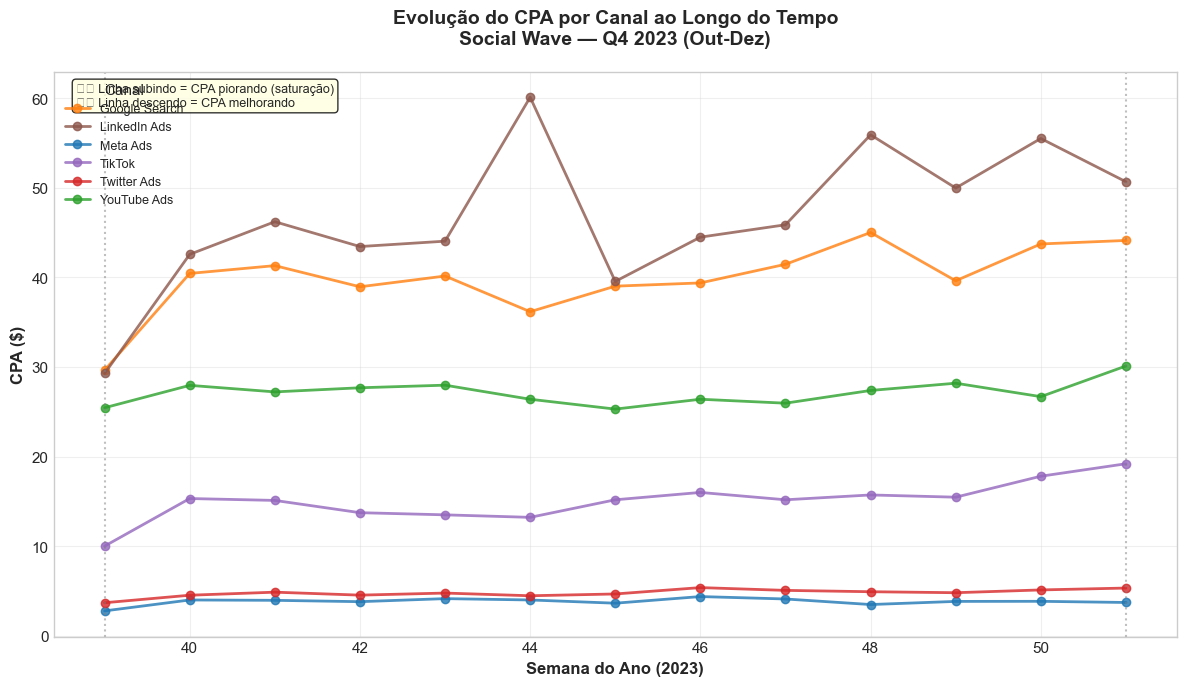


📊 TENDÊNCIA DO CPA NO TRIMESTRE

Canal               CPA Inicial    CPA Final   Variação Tendência
---------------------------------------------------------------------------
Google Search      $     29.64 $     44.11     +48.8%   ⚠️ SUBINDO
LinkedIn Ads       $     29.27 $     50.66     +73.1%   ⚠️ SUBINDO
Meta Ads           $      2.77 $      3.71     +33.9%   ➖ ESTÁVEL
TikTok             $     10.00 $     19.19     +91.9%   ⚠️ SUBINDO
Twitter Ads        $      3.68 $      5.32     +44.6%   ⚠️ SUBINDO
YouTube Ads        $     25.44 $     30.10     +18.3%   ➖ ESTÁVEL

💡 INTERPRETAÇÃO:
   Se CPA subiu no trimestre = canal já estava saturando ANTES do aumento de verba
   Isso fortalece o argumento para realocar investimento em vez de apenas aumentar


In [8]:
print('=' * 60)
print('📊 GRÁFICO: EVOLUÇÃO TEMPORAL DO CPA')
print('=' * 60)

# ============================================================
# PREPARAR DADOS TEMPORAIS
# ============================================================

# Criar coluna de semana para agregação
df['Semana'] = df['Data da Coleta'].dt.isocalendar().week

# Agregar por canal + semana (apenas registros com conversão > 0)
df_tempo = df[df['Conversao'] > 0].copy()

# Agrupar por canal e semana
evolucao = df_tempo.groupby(['Canal_Nome', 'Semana']).agg({
    'Gasto': 'sum',
    'Conversao': 'sum'
}).reset_index()

# Calcular CPA semanal
evolucao['CPA'] = (evolucao['Gasto'] / evolucao['Conversao']).round(2)

print(f'✅ Dados agregados por semana e canal')
print(f'   Período: semanas {evolucao['Semana'].min()} a {evolucao['Semana'].max()}')

# ============================================================
# CRIAR GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

# Cores por canal
cores_canal = {
    'Meta Ads': '#1f77b4',
    'Google Search': '#ff7f0e',
    'YouTube Ads': '#2ca02c',
    'Twitter Ads': '#d62728',
    'TikTok': '#9467bd',
    'LinkedIn Ads': '#8c564b'
}

# Plotar linha por canal
for canal in sorted(evolucao['Canal_Nome'].unique()):
    dados_canal = evolucao[evolucao['Canal_Nome'] == canal]
    
    ax.plot(
        dados_canal['Semana'],
        dados_canal['CPA'],
        marker='o',
        linewidth=2,
        markersize=6,
        label=canal,
        color=cores_canal.get(canal, 'gray'),
        alpha=0.8
    )

# ============================================================
# CONFIGURAR ESTILO
# ============================================================

ax.set_xlabel('Semana do Ano (2023)', fontsize=12, fontweight='bold')
ax.set_ylabel('CPA ($)', fontsize=12, fontweight='bold')
ax.set_title(
    'Evolução do CPA por Canal ao Longo do Tempo\nSocial Wave — Q4 2023 (Out-Dez)',
    fontsize=14,
    fontweight='bold',
    pad=20
)

# Destacar início e fim do trimestre
ax.axvline(x=evolucao['Semana'].min(), color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=evolucao['Semana'].max(), color='gray', linestyle=':', alpha=0.5)

ax.legend(loc='upper left', fontsize=9, title='Canal')
ax.grid(alpha=0.3)

# Anotação de tendência
ax.text(
    0.02, 0.98,
    '⬆️ Linha subindo = CPA piorando (saturação)\n⬇️ Linha descendo = CPA melhorando',
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

plt.tight_layout()

# ============================================================
# SALVAR FIGURA
# ============================================================

figura_path = r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\images\04_evolucao_cpa_temporal.png'
plt.savefig(figura_path, dpi=150, bbox_inches='tight')
print(f'✅ Figura salva: {figura_path}')

# ============================================================
# EXIBIR
# ============================================================

plt.show()

# ============================================================
# ANÁLISE DE TENDÊNCIA
# ============================================================

print('\n' + '=' * 60)
print('📊 TENDÊNCIA DO CPA NO TRIMESTRE')
print('=' * 60)

from scipy import stats

print(f'\n{'Canal':<18} {'CPA Inicial':>12} {'CPA Final':>12} {'Variação':>10} {'Tendência'}')
print('-' * 75)

for canal in sorted(evolucao['Canal_Nome'].unique()):
    dados = evolucao[evolucao['Canal_Nome'] == canal].sort_values('Semana')
    
    if len(dados) >= 2:
        cpa_inicial = dados['CPA'].iloc[0]
        cpa_final = dados['CPA'].iloc[-1]
        variacao = ((cpa_final / cpa_inicial) - 1) * 100
        
        # Regressão linear para tendência
        slope, _, r_value, p_value, _ = stats.linregress(dados['Semana'], dados['CPA'])
        
        if slope > 0 and p_value < 0.1:
            tendencia = '⚠️ SUBINDO'
        elif slope < 0 and p_value < 0.1:
            tendencia = '✅ DESCENDO'
        else:
            tendencia = '➖ ESTÁVEL'
        
        print(f'{canal:<18} ${cpa_inicial:>10.2f} ${cpa_final:>10.2f} {variacao:>+9.1f}%   {tendencia}')
    else:
        print(f'{canal:<18} {'Dados insuficientes':>50}')

print(f'\n💡 INTERPRETAÇÃO:')
print(f'   Se CPA subiu no trimestre = canal já estava saturando ANTES do aumento de verba')
print(f'   Isso fortalece o argumento para realocar investimento em vez de apenas aumentar')

| Padrão             | Significado                      | Argumento para o relatório                                |
| ------------------ | -------------------------------- | --------------------------------------------------------- |
| **Linha subindo**  | CPA piorando ao longo do tempo   | Canal já estava saturado — aumentar verba pioraria        |
| **Linha descendo** | CPA melhorando ao longo do tempo | Canal com escala benéfica — candidato a mais investimento |
| **Linha estável**  | CPA constante                    | Canal previsível — manter alocação atual                  |


## Gráfico de Barras: CTR e Taxa de Conversão por Canal

Mostra duas métricas do funil lado a lado para cada canal: CTR (quão atrativo é o anúncio) e Taxa de Conversão (quão eficiente é a página de destino/oferta). 

Identifica onde o funil "vaza": se CTR é baixo, o problema é o criativo; se Taxa de Conversão é baixa, o problema é pós-clique.

📊 GRÁFICO: CTR E TAXA DE CONVERSÃO POR CANAL
✅ Figura salva: C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\images\05_ctr_vs_taxa_conversao.png


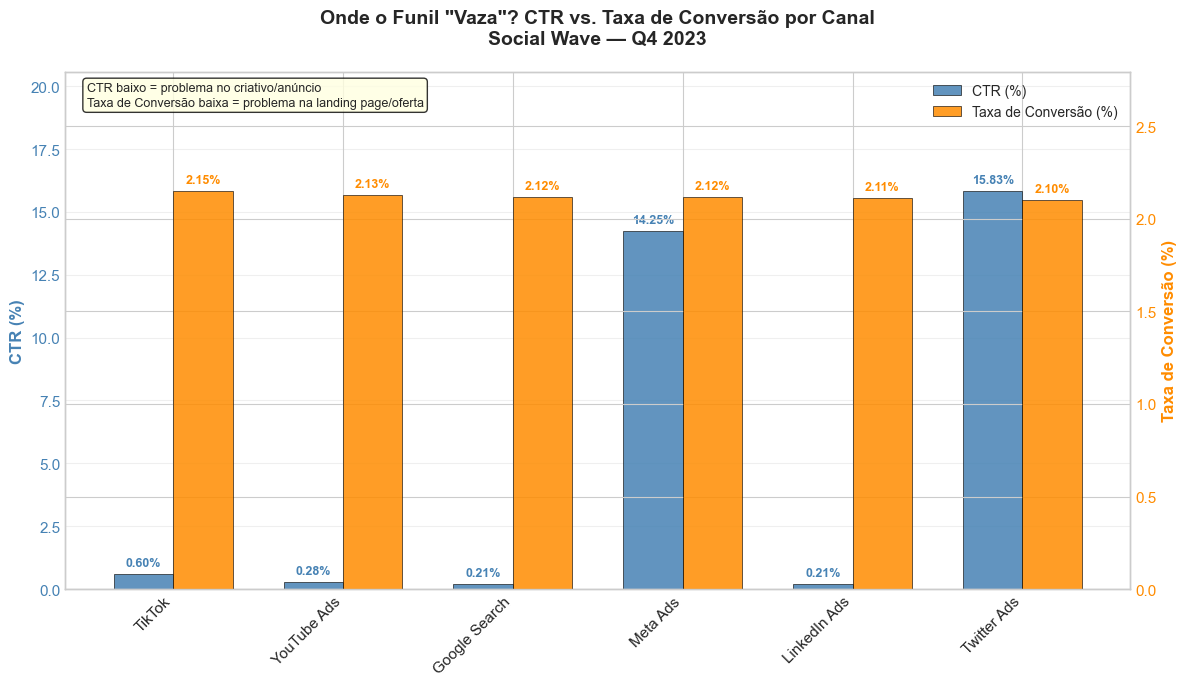


🔍 DIAGNÓSTICO DO FUNIL POR CANAL

📏 Referências (medianas): CTR = 0.44% | Taxa de Conversão = 2.12%

Canal                     CTR     Status CTR  Tx. Conversão   Status Conv. Diagnóstico
--------------------------------------------------------------------------------------------------------------
TikTok                  0.60%          ✅ Bom          2.15%          ✅ Boa   🟢 Funil saudável
YouTube Ads             0.28%       ⚠️ Baixo          2.13%          ✅ Boa   🟡 Problema no criativo (CTR baixo)
Google Search           0.21%       ⚠️ Baixo          2.12%          ✅ Boa   🟡 Problema no criativo (CTR baixo)
Meta Ads               14.25%          ✅ Bom          2.12%          ✅ Boa   🟢 Funil saudável
LinkedIn Ads            0.21%       ⚠️ Baixo          2.11%       ⚠️ Baixa   🔴 Funil quebrado (CTR e Conversão baixos)
Twitter Ads            15.83%          ✅ Bom          2.10%       ⚠️ Baixa   🟠 Problema pós-clique (landing page)

💡 INTERPRETAÇÃO:
   🟢 = Canal saudável — manter estrat

In [10]:
print('=' * 60)
print('📊 GRÁFICO: CTR E TAXA DE CONVERSÃO POR CANAL')
print('=' * 60)

# ============================================================
# PREPARAR DADOS
# ============================================================

# Usar o resumo já calculado na Célula 4
# Ordenar por Taxa de Conversão (do maior para o menor)
resumo_funnel = resumo.sort_values('Taxa_Conversao', ascending=False)

# ============================================================
# CRIAR GRÁFICO COM DOIS EIXOS Y
# ============================================================

fig, ax1 = plt.subplots(figsize=(12, 7))

x = np.arange(len(resumo_funnel))
largura = 0.35

# --- Eixo Y esquerdo: CTR ---
barras_ctr = ax1.bar(
    x - largura/2,
    resumo_funnel['CTR'],
    largura,
    label='CTR (%)',
    color='steelblue',
    edgecolor='black',
    linewidth=0.5,
    alpha=0.85
)

ax1.set_xlabel('')
ax1.set_ylabel('CTR (%)', fontsize=12, fontweight='bold', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(0, max(resumo_funnel['CTR']) * 1.3)

# --- Eixo Y direito: Taxa de Conversão ---
ax2 = ax1.twinx()

barras_conv = ax2.bar(
    x + largura/2,
    resumo_funnel['Taxa_Conversao'],
    largura,
    label='Taxa de Conversão (%)',
    color='darkorange',
    edgecolor='black',
    linewidth=0.5,
    alpha=0.85
)

ax2.set_ylabel('Taxa de Conversão (%)', fontsize=12, fontweight='bold', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.set_ylim(0, max(resumo_funnel['Taxa_Conversao']) * 1.3)

# --- Eixo X: nomes dos canais ---
ax1.set_xticks(x)
ax1.set_xticklabels(resumo_funnel.index, rotation=45, ha='right')

# ============================================================
# ADICIONAR VALORES NAS BARRAS
# ============================================================

for i, (canal, row) in enumerate(resumo_funnel.iterrows()):
    # CTR
    ax1.text(
        x=i - largura/2,
        y=row['CTR'] + (max(resumo_funnel['CTR']) * 0.02),
        s=f'{row['CTR']:.2f}%',
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='steelblue'
    )
    # Taxa de Conversão
    ax2.text(
        x=i + largura/2,
        y=row['Taxa_Conversao'] + (max(resumo_funnel['Taxa_Conversao']) * 0.02),
        s=f'{row['Taxa_Conversao']:.2f}%',
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='darkorange'
    )

# ============================================================
# CONFIGURAR ESTILO
# ============================================================

ax1.set_title(
    'Onde o Funil "Vaza"? CTR vs. Taxa de Conversão por Canal\nSocial Wave — Q4 2023',
    fontsize=14,
    fontweight='bold',
    pad=20
)

# Legenda combinada
linhas1, rotulos1 = ax1.get_legend_handles_labels()
linhas2, rotulos2 = ax2.get_legend_handles_labels()
ax1.legend(linhas1 + linhas2, rotulos1 + rotulos2, loc='upper right', fontsize=10)

ax1.grid(axis='y', alpha=0.3)

# Anotação explicativa
ax1.text(
    0.02, 0.98,
    'CTR baixo = problema no criativo/anúncio\nTaxa de Conversão baixa = problema na landing page/oferta',
    transform=ax1.transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

plt.tight_layout()

# ============================================================
# SALVAR FIGURA
# ============================================================

figura_path = r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\images\05_ctr_vs_taxa_conversao.png'
plt.savefig(figura_path, dpi=150, bbox_inches='tight')
print(f'✅ Figura salva: {figura_path}')

# ============================================================
# EXIBIR
# ============================================================

plt.show()

# ============================================================
# DIAGNÓSTICO DO FUNIL
# ============================================================

print('\n' + '=' * 60)
print('🔍 DIAGNÓSTICO DO FUNIL POR CANAL')
print('=' * 60)

# Calcular medianas para referência
mediana_ctr = resumo_funnel['CTR'].median()
mediana_conv = resumo_funnel['Taxa_Conversao'].median()

print(f'\n📏 Referências (medianas): CTR = {mediana_ctr:.2f}% | Taxa de Conversão = {mediana_conv:.2f}%')

print(f'\n{'Canal':<18} {'CTR':>10} {'Status CTR':>14} {'Tx. Conversão':>14} {'Status Conv.':>14} {'Diagnóstico'}')
print('-' * 110)

for canal in resumo_funnel.index:
    row = resumo_funnel.loc[canal]
    ctr = row['CTR']
    conv = row['Taxa_Conversao']
    
    status_ctr = '✅ Bom' if ctr >= mediana_ctr else '⚠️ Baixo'
    status_conv = '✅ Boa' if conv >= mediana_conv else '⚠️ Baixa'
    
    # Diagnóstico combinado
    if ctr >= mediana_ctr and conv >= mediana_conv:
        diag = '🟢 Funil saudável'
    elif ctr < mediana_ctr and conv >= mediana_conv:
        diag = '🟡 Problema no criativo (CTR baixo)'
    elif ctr >= mediana_ctr and conv < mediana_conv:
        diag = '🟠 Problema pós-clique (landing page)'
    else:
        diag = '🔴 Funil quebrado (CTR e Conversão baixos)'
    
    print(f'{canal:<18} {ctr:>9.2f}% {status_ctr:>14} {conv:>13.2f}% {status_conv:>14}   {diag}')

print(f'\n💡 INTERPRETAÇÃO:')
print(f'   🟢 = Canal saudável — manter estratégia')
print(f'   🟡 = Criativo não atrai — testar novas peças')
print(f'   🟠 = Tráfego chega mas não converte — revisar landing page/oferta')
print(f'   🔴 = Problema em ambos — revisar estratégia completa do canal')

| Combinação                      | Diagnóstico        | Ação recomendada          |
| ------------------------------- | ------------------ | ------------------------- |
| **CTR alto + Conversão alta**   | Funil saudável     | Manter e escalar          |
| **CTR baixo + Conversão alta**  | Criativo fraco     | Testar novos anúncios     |
| **CTR alto + Conversão baixa**  | Landing page fraca | Revisar página de destino |
| **CTR baixo + Conversão baixa** | Canal ineficiente  | Reconsiderar presença     |


## Matriz de Correlação

Exibe uma heatmap de correlações entre todas as variáveis numéricas do projeto. 

Revela relações ocultas: por exemplo, 

    - se Gasto e CPA são positivamente correlacionados, confirma retornos decrescentes; 
    - se CTR e Taxa_Conversao são correlacionados, indica que canais bons em atração também são bons em conversão.

📊 MATRIZ DE CORRELAÇÃO

------------------------------------------------------------
1. VARIÁVEIS SELECIONADAS
------------------------------------------------------------
✅ Variáveis incluídas: 12
   • Impressoes Disponiveis
   • Consultas Correspondentes
   • Impressoes
   • Cliques
   • Gasto
   • Conversao
   • CTR
   • Taxa_Conversao
   • CPC
   • CPA
   • CPM
   • Taxa_Impressao

📊 Registros com CPA válido: 22,615

------------------------------------------------------------
2. MATRIZ DE CORRELAÇÃO DE PEARSON
------------------------------------------------------------

📋 Matriz completa:
                           Impressoes Disponiveis  Consultas Correspondentes  Impressoes  Cliques  Gasto  Conversao   CTR  Taxa_Conversao   CPC   CPA   CPM  Taxa_Impressao
Impressoes Disponiveis                       1.00                       0.99        0.99     0.10   0.89       0.09 -0.46           -0.09  0.55  0.52 -0.45            0.15
Consultas Correspondentes                    0.99     

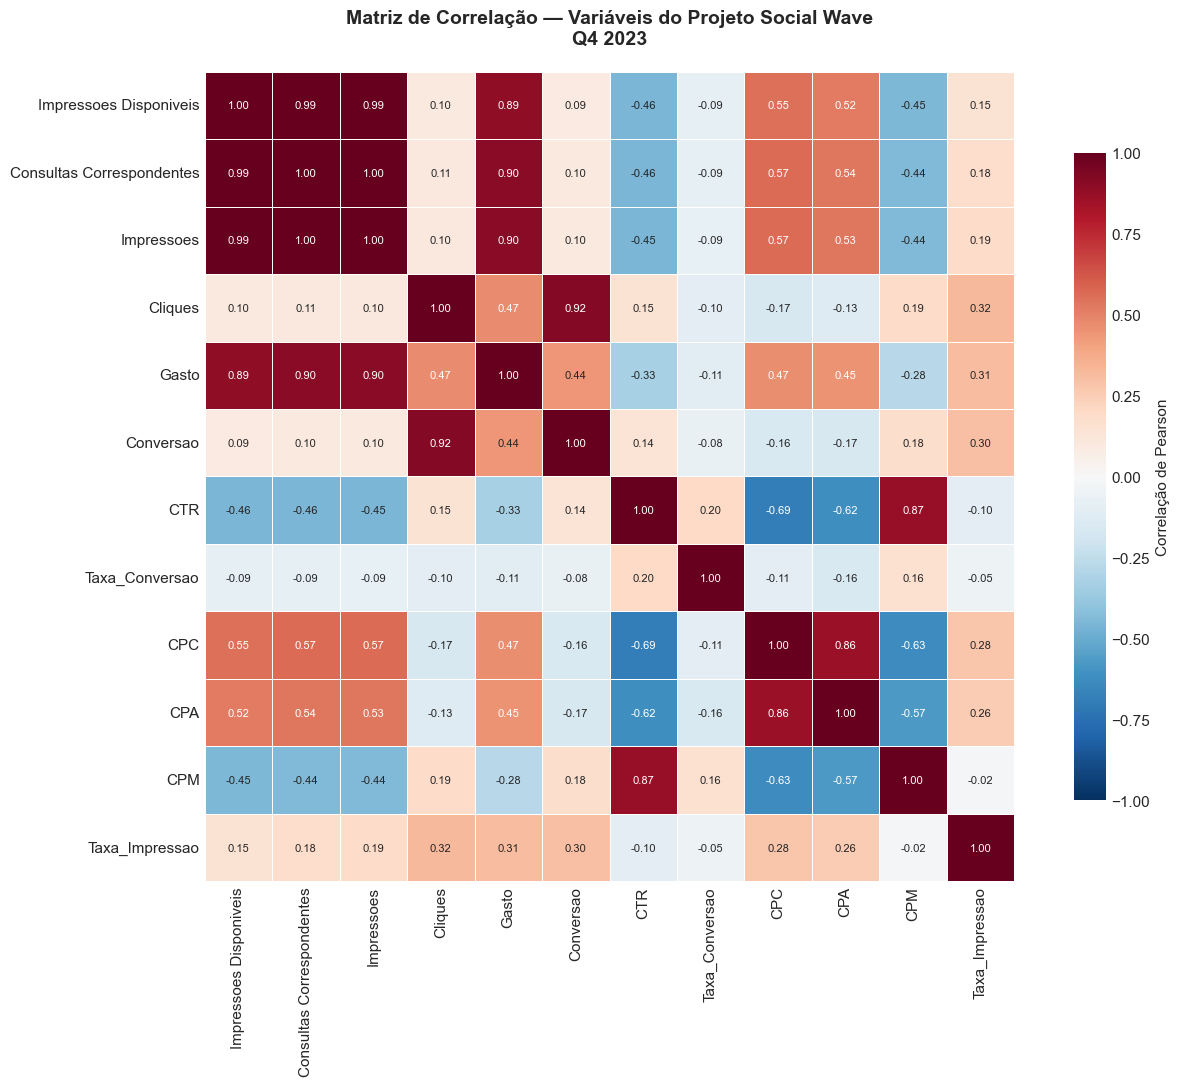


🔍 CORRELAÇÕES MAIS RELEVANTES PARA O NEGÓCIO

📊 Correlações com |r| >= 0.50:

Var1                      Var2                             r      Força    Direção
-------------------------------------------------------------------------------------
Consultas Correspondentes Impressoes                  +0.999      Forte 📈 Positiva
Impressoes Disponiveis    Consultas Correspondentes   +0.995      Forte 📈 Positiva
Impressoes Disponiveis    Impressoes                  +0.994      Forte 📈 Positiva
Cliques                   Conversao                   +0.921      Forte 📈 Positiva
Consultas Correspondentes Gasto                       +0.903      Forte 📈 Positiva
Impressoes                Gasto                       +0.901      Forte 📈 Positiva
Impressoes Disponiveis    Gasto                       +0.890      Forte 📈 Positiva
CTR                       CPM                         +0.869      Forte 📈 Positiva
CPC                       CPA                         +0.860      Forte 📈 Positiva
CTR  

In [13]:
print('=' * 60)
print('📊 MATRIZ DE CORRELAÇÃO')
print('=' * 60)

# ============================================================
# SELECIONAR VARIÁVEIS NUMÉRICAS
# ============================================================

print('\n' + '-' * 60)
print('1. VARIÁVEIS SELECIONADAS')
print('-' * 60)

# Colunas numéricas relevantes para análise
colunas_corr = [
    'Impressoes Disponiveis',
    'Consultas Correspondentes',
    'Impressoes',
    'Cliques',
    'Gasto',
    'Conversao',
    'CTR',
    'Taxa_Conversao',
    'CPC',
    'CPA',
    'CPM',
    'Taxa_Impressao'
]

# Filtrar apenas registros com CPA finito para inclusão na matriz
df_corr = df[df['Conversao'] > 0][colunas_corr].copy()

print(f'✅ Variáveis incluídas: {len(colunas_corr)}')
for col in colunas_corr:
    print(f'   • {col}')

print(f'\n📊 Registros com CPA válido: {len(df_corr):,}')

# ============================================================
# CALCULAR MATRIZ DE CORRELAÇÃO
# ============================================================

print('\n' + '-' * 60)
print('2. MATRIZ DE CORRELAÇÃO DE PEARSON')
print('-' * 60)

matriz_corr = df_corr.corr().round(3)

print('\n📋 Matriz completa:')
print(matriz_corr.to_string())

# ============================================================
# VISUALIZAR HEATMAP
# ============================================================

print('\n' + '-' * 60)
print('3. HEATMAP DE CORRELAÇÕES')
print('-' * 60)

fig, ax = plt.subplots(figsize=(14, 11))

# Criar heatmap
heatmap = sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Correlação de Pearson'},
    ax=ax
)

# Ajustar tamanho das anotações
for text in heatmap.texts:
    text.set_fontsize(8)

ax.set_title(
    'Matriz de Correlação — Variáveis do Projeto Social Wave\nQ4 2023',
    fontsize=14,
    fontweight='bold',
    pad=20
)

plt.tight_layout()

# ============================================================
# SALVAR FIGURA
# ============================================================

figura_path = r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\images\06_matriz_correlacao.png'
plt.savefig(figura_path, dpi=150, bbox_inches='tight')
print(f'✅ Figura salva: {figura_path}')

# ============================================================
# EXIBIR
# ============================================================

plt.show()

# ============================================================
# DESTACAR CORRELAÇÕES MAIS RELEVANTES
# ============================================================

print('\n' + '=' * 60)
print('🔍 CORRELAÇÕES MAIS RELEVANTES PARA O NEGÓCIO')
print('=' * 60)

# Função para extrair correlações acima de um limiar (ignorando diagonal)
def extrair_correlacoes_fortes(matriz, limiar=0.5):
    pares = []
    for i in range(len(matriz.columns)):
        for j in range(i+1, len(matriz.columns)):
            corr = matriz.iloc[i, j]
            if abs(corr) >= limiar:
                pares.append({
                    'Var1': matriz.columns[i],
                    'Var2': matriz.columns[j],
                    'Correlacao': corr,
                    'Forca': 'Forte' if abs(corr) >= 0.7 else 'Moderada',
                    'Direcao': 'Positiva' if corr > 0 else 'Negativa'
                })
    return pd.DataFrame(pares).sort_values('Correlacao', key=abs, ascending=False)

correlacoes_fortes = extrair_correlacoes_fortes(matriz_corr, limiar=0.5)

if len(correlacoes_fortes) > 0:
    print(f'\n📊 Correlações com |r| >= 0.50:')
    print(f'\n{'Var1':<25} {'Var2':<25} {'r':>8} {'Força':>10} {'Direção':>10}')
    print('-' * 85)
    
    for _, row in correlacoes_fortes.iterrows():
        simbolo = '📈' if row['Direcao'] == 'Positiva' else '📉'
        print(f'{row['Var1']:<25} {row['Var2']:<25} {row['Correlacao']:>+8.3f} {row['Forca']:>10} {simbolo} {row['Direcao']}')
else:
    print('\n➖ Nenhuma correlação forte (|r| >= 0.50) encontrada')

# ============================================================
# INSIGHTS ESPECÍFICOS DO PROJETO
# ============================================================

print('\n' + '=' * 60)
print('💡 INSIGHTS ESPECÍFICOS')
print('=' * 60)

# Verificar correlações chave para o projeto
insights = []

# Gasto vs. CPA (retornos decrescentes?)
gasto_cpa = matriz_corr.loc['Gasto', 'CPA']
if gasto_cpa > 0.3:
    insights.append(f'⚠️  Gasto vs. CPA: r = {gasto_cpa:+.3f} → Retornos decrescentes detectados')
elif gasto_cpa < -0.3:
    insights.append(f'✅ Gasto vs. CPA: r = {gasto_cpa:+.3f} → Escala benéfica')
else:
    insights.append(f'➖ Gasto vs. CPA: r = {gasto_cpa:+.3f} → Sem relação clara')

# CTR vs. Taxa de Conversão (canal bom em tudo?)
ctr_conv = matriz_corr.loc['CTR', 'Taxa_Conversao']
if ctr_conv > 0.3:
    insights.append(f'✅ CTR vs. Taxa de Conversão: r = {ctr_conv:+.3f} → Canais bons em atração também convertem bem')
elif ctr_conv < -0.3:
    insights.append(f'⚠️  CTR vs. Taxa de Conversão: r = {ctr_conv:+.3f} → Trade-off: atrair vs. converter')
else:
    insights.append(f'➖ CTR vs. Taxa de Conversão: r = {ctr_conv:+.3f} → Métricas independentes')

# Impressões vs. CTR (saturação de inventário?)
imp_ctr = matriz_corr.loc['Impressoes', 'CTR']
if imp_ctr < -0.3:
    insights.append(f'⚠️  Impressões vs. CTR: r = {imp_ctr:+.3f} → Mais impressões = CTR menor (fadiga de audiência)')
else:
    insights.append(f'➖ Impressões vs. CTR: r = {imp_ctr:+.3f} → Sem evidência de fadiga')

# Gasto vs. Conversão (eficiência de escala)
gasto_conv = matriz_corr.loc['Gasto', 'Conversao']
if gasto_conv > 0.7:
    insights.append(f'✅ Gasto vs. Conversão: r = {gasto_conv:+.3f} → Mais gasto = mais conversões (escala funciona)')
else:
    insights.append(f'⚠️  Gasto vs. Conversão: r = {gasto_conv:+.3f} → Relação fraca (dinheiro não garante conversão)')

for insight in insights:
    print(f'\n{insight}')

print('\n' + '=' * 60)
print('🚀 MATRIZ DE CORRELAÇÃO COMPLETA!')
print('=' * 60)

| Correlação                         | Significado                   | Implicação                           |
| ---------------------------------- | ----------------------------- | ------------------------------------ |
| **Gasto ↔ CPA positiva**           | Retornos decrescentes         | Aumentar verba piora eficiência      |
| **Gasto ↔ Conversão fraca**        | Dinheiro não compra conversão | Qualidade > quantidade               |
| **CTR ↔ Taxa\_Conversao positiva** | Canais bons em tudo           | Dificil separar atração de conversão |
| **Impressões ↔ CTR negativa**      | Fadiga de audiência           | Mais alcance ≠ mais cliques          |


## Resumo Executivo do EDA

In [14]:
print('=' * 60)
print('📋 RESUMO EXECUTIVO — DIAGNÓSTICO SOCIAL WAVE')
print('=' * 60)

# ============================================================
# COLETAR MÉTRICAS CHAVE
# ============================================================

print('\n' + '-' * 60)
print('MÉTRICAS CHAVE DO PERÍODO')
print('-' * 60)

gasto_total = df['Gasto'].sum()
conversao_total = df['Conversao'].sum()
cpa_global = gasto_total / conversao_total
registros_total = len(df)

print(f'\n📊 Período analisado: Outubro a Dezembro de 2023')
print(f'📊 Registros analisados: {registros_total:,}')
print(f'💰 Gasto total: ${gasto_total:,.2f}')
print(f'🎯 Conversões totais: {conversao_total:,}')
print(f'📏 CPA global: ${cpa_global:.2f}')

# ============================================================
# RANKING DE EFICIÊNCIA (CPA)
# ============================================================

print('\n' + '-' * 60)
print('RANKING DE EFICIÊNCIA POR CANAL')
print('-' * 60)

resumo_ranking = resumo.sort_values('CPA')

print(f'\n{'Pos':>4} {'Canal':<18} {'CPA':>10} {'Share Gasto':>12} {'Share Conv.':>12} {'Status'}')
print('-' * 75)

for pos, (canal, row) in enumerate(resumo_ranking.iterrows(), 1):
    diff = row['Diferenca_Share']
    if diff > 10:
        status = '⚠️ Sobre-investido'
    elif diff < -10:
        status = '💡 Sub-investido'
    else:
        status = '✅ Balanceado'
    
    print(f'{pos:>4} {canal:<18} ${row['CPA']:>8.2f} {row['Share_Gasto']:>10.1f}% {row['Share_Conversao']:>10.1f}%   {status}')

# ============================================================
# PROBLEMAS IDENTIFICADOS
# ============================================================

print('\n' + '-' * 60)
print('PROBLEMAS IDENTIFICADOS')
print('-' * 60)

problemas = []

# Problema 1: Desbalanceamento
sobre_investidos = resumo[resumo['Diferenca_Share'] > 10]
if len(sobre_investidos) > 0:
    for canal in sobre_investidos.index:
        row = sobre_investidos.loc[canal]
        problemas.append(f'⚠️  {canal}: gasta {row['Share_Gasto']:.1f}% do orçamento para apenas {row['Share_Conversao']:.1f}% das conversões')

# Problema 2: Ineficiência
canal_menos_eficiente = resumo['CPA'].idxmax()
cpa_alto = resumo.loc[canal_menos_eficiente, 'CPA']
cpa_baixo = resumo['CPA'].min()
if cpa_alto > cpa_baixo * 2:
    problemas.append(f'⚠️  Diferença extrema de eficiência: {canal_menos_eficiente} custa {cpa_alto/cpa_baixo:.1f}x mais que o canal mais eficiente')

# Problema 3: Zeros em conversão
taxa_zero = (df['Conversao'] == 0).mean() * 100
if taxa_zero > 5:
    problemas.append(f'⚠️  {taxa_zero:.1f}% das campanhas não converteram — desperdício significativo')

if problemas:
    print(f'\n🚨 {len(problemas)} problema(s) crítico(s) identificado(s):')
    for p in problemas:
        print(f'   {p}')
else:
    print('\n✅ Nenhum problema crítico identificado')

# ============================================================
# OPORTUNIDADES
# ============================================================

print('\n' + '-' * 60)
print('OPORTUNIDADES DE OTIMIZAÇÃO')
print('-' * 60)

oportunidades = []

# Oportunidade 1: Realocar de sobre para sub-investido
sub_investidos = resumo[resumo['Diferenca_Share'] < -10]
if len(sub_investidos) > 0 and len(sobre_investidos) > 0:
    canal_origem = sobre_investidos['Diferenca_Share'].idxmax()
    canal_destino = sub_investidos['Diferenca_Share'].idxmin()
    oportunidades.append(f'💡 Realocar verba de {canal_origem} (sobre-investido) para {canal_destino} (sub-investido)')

# Oportunidade 2: Escala no canal mais eficiente
canal_top = resumo['CPA'].idxmin()
share_top = resumo.loc[canal_top, 'Share_Gasto']
if share_top < 25:
    oportunidades.append(f'💡 Aumentar investimento em {canal_top} (mais eficiente) — atualmente só {share_top:.1f}% do orçamento')

# Oportunidade 3: Corrigir funil
canal_ctr_baixo = resumo['CTR'].idxmin()
canal_conv_baixa = resumo['Taxa_Conversao'].idxmin()
if canal_ctr_baixo == canal_conv_baixa:
    oportunidades.append(f'💡 Revisar estratégia completa de {canal_ctr_baixo} — CTR e Taxa de Conversão baixos')
else:
    oportunidades.append(f'💡 Melhorar criativos de {canal_ctr_baixo} (CTR baixo) e landing page de {canal_conv_baixa} (conversão baixa)')

print(f'\n🎯 {len(oportunidades)} oportunidade(s) identificada(s):')
for o in oportunidades:
    print(f'   {o}')

# ============================================================
# PRÓXIMAS ETAPAS
# ============================================================

print('\n' + '-' * 60)
print('PRÓXIMAS ETAPAS DO PROJETO')
print('-' * 60)

print(f'''
📋 O que já fizemos (Notebook 01):
   ✅ Diagnóstico completo — sabemos ONDE está o problema

📋 O que vem a seguir:
   🔜 Notebook 02 — Análise de CPA: decompor o CPA em seus componentes
   🔜 Notebook 03 — Modelo de Otimização: simular cenários de realocação
   🔜 Notebook 04 — Resumo Executivo: apresentação para gestores

🎯 Pergunta central que falta responder:
   "Se realocarmos X% do orçamento do canal A para o canal B,
    quanto o CPA global cai e quantas conversões a mais ganhamos?"
''')

# ============================================================
# SALVAR RESUMO PARA NOTEBOOK 04
# ============================================================

print('\n' + '-' * 60)
print('SALVAR RESUMO EXECUTIVO')
print('-' * 60)

resumo_executivo = f'''
================================================================
RESUMO EXECUTIVO — DIAGNÓSTICO SOCIAL WAVE (Q4 2023)
Gerado em: {datetime.now().strftime('%Y-%m-%d %H:%M')}
================================================================

1. CONTEXTO
   Empresa: Social Wave (marketing digital)
   Problema: CPA disparou após aumento igualitário de verba
   Período analisado: Outubro a Dezembro de 2023
   Registros: {registros_total:,}
   Gasto total: ${gasto_total:,.2f}
   Conversões: {conversao_total:,}
   CPA global: ${cpa_global:.2f}

2. RANKING DE EFICIÊNCIA (CPA — menor = melhor)
'''

for pos, (canal, row) in enumerate(resumo_ranking.iterrows(), 1):
    resumo_executivo += f'   {pos}. {canal}: ${row['CPA']:.2f} (Gasto: {row['Share_Gasto']:.1f}%, Conv: {row['Share_Conversao']:.1f}%)\n'

resumo_executivo += f'''
3. PROBLEMAS CRÍTICOS
'''
for p in problemas:
    resumo_executivo += f'   {p}\n'

resumo_executivo += f'''
4. OPORTUNIDADES
'''
for o in oportunidades:
    resumo_executivo += f'   {o}\n'

resumo_executivo += f'''
5. RECOMENDAÇÃO PRELIMINAR
   O aumento igualitário de verba foi ineficiente porque ignorou
   a assimetria de performance entre canais. A realocação baseada
   em CPA (mais verba para canais eficientes, menos para ineficientes)
   é matematicamente superior à alocação uniforme.

================================================================
'''

# Salvar em arquivo
resumo_path = r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\data\resumo_executivo_eda.txt'
with open(resumo_path, 'w', encoding='utf-8') as f:
    f.write(resumo_executivo)

print(f'✅ Resumo salvo: {resumo_path}')

# ============================================================
# EXIBIR RESUMO COMPLETO
# ============================================================

print('\n' + '=' * 60)
print('📄 RESUMO EXECUTIVO COMPLETO')
print('=' * 60)
print(resumo_executivo)

print('=' * 60)
print('🎉 NOTEBOOK 01 — ANÁLISE EXPLORATÓRIA CONCLUÍDA!')
print('=' * 60)

📋 RESUMO EXECUTIVO — DIAGNÓSTICO SOCIAL WAVE

------------------------------------------------------------
MÉTRICAS CHAVE DO PERÍODO
------------------------------------------------------------

📊 Período analisado: Outubro a Dezembro de 2023
📊 Registros analisados: 23,315
💰 Gasto total: $65,701,095.65
🎯 Conversões totais: 5,711,699
📏 CPA global: $11.50

------------------------------------------------------------
RANKING DE EFICIÊNCIA POR CANAL
------------------------------------------------------------

 Pos Canal                     CPA  Share Gasto  Share Conv. Status
---------------------------------------------------------------------------
   1 Meta Ads           $    3.88        9.2%       27.2%   💡 Sub-investido
   2 Twitter Ads        $    4.86       19.2%       45.5%   💡 Sub-investido
   3 TikTok             $   15.35        8.6%        6.4%   ✅ Balanceado
   4 YouTube Ads        $   27.22       22.1%        9.3%   ⚠️ Sobre-investido
   5 Google Search      $   40.76       